# Challenge $0$


## 1. ***Data cleaning with Pandas***

Use the library `pandas` to load and clean the required dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

Obtain the data file

In [2]:
FFILE = './50_Startups.csv'
if os.path.isfile(FFILE):
    print("File already exists")
    if os.access(FFILE, os.R_OK):
        print ("File is readable")
    else:
        print ("File is not readable, removing it and downloading again")
        !rm FFILE
        !curl -o "50_Startups.csv" "https://raw.githubusercontent.com/alexdepremia/ML_IADA_UTs/refs/heads/main/challenge_0/50_Startups.csv"
else:
    print("Either the file is missing or not readable, download it")
    !curl -o "50_Startups.csv" "https://raw.githubusercontent.com/alexdepremia/ML_IADA_UTs/refs/heads/main/challenge_0/50_Startups.csv"

File already exists
File is readable


In [3]:
import pandas as pd

# Load the dataset using Pandas
data = pd.read_csv('50_Startups.csv')

# Extracting the features (independent variables) and labels (dependent variable)
# Features (X) are taken from all columns except the last two
features = data.iloc[:, :-2].values

# Labels (y) are taken from the third column (index 3, considering the 0-based index in Python)
labels = data.iloc[:, 3].values

df = pd.DataFrame(data)

In [4]:
labels

array(['New York', 'California', 'Florida', 'New York', 'Florida',
       'New York', 'California', 'Florida', 'New York', 'California',
       'Florida', 'California', 'Florida', 'California', 'Florida',
       'New York', 'California', 'New York', 'Florida', 'New York',
       'California', 'New York', 'Florida', 'Florida', 'New York',
       'California', 'Florida', 'New York', 'Florida', 'New York',
       'Florida', 'New York', 'California', 'Florida', 'California',
       'New York', 'Florida', 'California', 'New York', 'California',
       'California', 'Florida', 'California', 'New York', 'California',
       'New York', 'Florida', 'California', 'New York', 'California'],
      dtype=object)

***Play with data***

In [5]:
df.shape

(50, 5)

In [6]:
df.replace(to_replace = 0.00, value = df.mean(axis=0, numeric_only=True), inplace=True)  # inject the mean of the column when value is 0
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


 **`df.replace()` function:**
   - This function is used to replace specific values within a DataFrame (`df`) with another value.
   - The parameters used are:
     - `to_replace=0.00`: This specifies the value in the DataFrame that needs to be replaced, in this case, `0.00`.
     - `value=df.mean(axis=0)`: This sets the replacement value for the matched condition. Here, `df.mean(axis=0)` calculates the mean for each column along the rows (axis=0) of the DataFrame `df`. The mean value for each column will replace the `0.00` values.
     - `inplace=True`: This parameter ensures that the modification is done directly on the original DataFrame (`df`) without creating a new DataFrame. If `inplace` is set to `True`, the original DataFrame is modified.

***Select two categories for binary classification***

In [7]:
df_sel=df[(df.State=="California") | (df.State=="Florida")]

In [8]:
df_sel.head() # column title and first rows of the dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
4,142107.34,91391.77,366168.42,Florida,166187.94
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60


In [9]:
df_sel.dtypes # type of each column

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

***Encode categorical data***

One-hot encoding of categorical feature _State_

One-Hot Encoding is a technique used in machine learning to handle categorical variables by transforming them into a format that can be easily utilized by algorithms.

Imagine having a categorical variable, such as colors: red, green, and blue. With One-Hot Encoding, each color becomes a new binary column. If an observation has a specific color, the column corresponding to that color will be set to 1, while the other columns will be set to 0.

For example:
- If you have categories "red", "green", "blue", and you want to encode them using One-Hot Encoding:
  - "red" becomes [1, 0, 0]
  - "green" becomes [0, 1, 0]
  - "blue" becomes [0, 0, 1]

This helps machine learning algorithms to understand and work with these categorical variables more effectively, as it doesn't impose an order or hierarchy among the categories but rather represents them in a form that the algorithm can interpret more efficiently.

In [10]:
df_one = pd.get_dummies(df_sel["State"], dtype=int)

In [11]:
df_one.head()

,California,Florida
1,1,0
2,0,1
4,0,1
6,1,0
7,0,1


In [12]:
# Constructing the final dataset for learning and prediction

# Concatenating two DataFrames 'df_one' and 'df_sel' along columns (axis=1)
df_fin = pd.concat((df_one, df_sel), axis=1)

# Dropping the column "Florida" from the dataset as it was not selected for the final model
df_fin = df_fin.drop(["Florida"], axis=1)

# Dropping the column "State" (assumed to be the original 'State' column) as it is not required in its original form
df_fin = df_fin.drop(["State"], axis=1)

# Renaming the column "California" to "State" as part of preparing the dataset for classification (1 for California, 0 for Florida)
df_fin = df_fin.rename(columns={"California": "State"})

# Displaying the initial rows of the modified final dataset
df_fin.head()

,State,R&D Spend,Administration,Marketing Spend,Profit
1,1,162597.70,151377.59,443898.53,191792.06
2,0,153441.51,101145.55,407934.54,191050.39
4,0,142107.34,91391.77,366168.42,166187.94
6,1,134615.46,147198.87,127716.82,156122.51
7,0,130298.13,145530.06,323876.68,155752.60


***Normalize***

Divide by the absolute value of the maximum so that features are in \[0, 1\]

In [13]:
def absolute_maximum_scale(series):
    """
    Scale each column in the DataFrame 'df_fin' by dividing the values by the absolute maximum value of that column.

    Args:
    series: A pandas Series or DataFrame column to be scaled.

    Returns:
    A scaled version of the input series with values ranging from -1 to 1 based on the maximum absolute value in the column.
    """
    return series / series.abs().max()

In [14]:
# Apply the 'absolute_maximum_scale' function to each column in the DataFrame 'df_fin'
for col in df_fin.columns:
    df_fin[col] = absolute_maximum_scale(df_fin[col])

In [15]:
df_fin.head()

,State,R&D Spend,Administration,Marketing Spend,Profit
1,1.0,1.000000,0.828805,1.000000,1.000000
2,0.0,0.943688,0.553781,0.918982,0.996133
4,0.0,0.873981,0.500378,0.824892,0.866501
6,1.0,0.827905,0.805926,0.287716,0.814020
7,0.0,0.801353,0.796789,0.729619,0.812091


In [16]:
df_fin.shape

(33, 5)

***Classification***

Prepare the dataset:

In [17]:
y = df_fin["State"] # ground truth labels
X = df_fin.drop(["State"], axis=1) # datapoints features
# extract actual values from series
y = y.values
X = X.values

Train test split

$75\%$ of the data are in the training set, the remaining $25\%$ constitutes the test set.

In [18]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
# X represents the features (independent variables), and y represents the target (dependent variable).

# Using train_test_split function to create the training and testing sets
# X_train and y_train: Training features and labels
# X_test and y_test: Testing features and labels

# The 'test_size=0.25' parameter sets the proportion of the dataset to include in the test split. Here, 25% of the data is allocated to the test set.
# The 'random_state=0' parameter sets the random seed for reproducibility of the split.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


Train the Logistic Regression Model

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
# Creating a Logistic Regression model with specific parameters
# - 'random_state=0' ensures reproducibility by setting the random seed.
# - 'solver='lbfgs'' selects the optimization algorithm for the logistic regression.

LR = LogisticRegression(random_state=0, solver='lbfgs').fit(X_train, y_train)

# Predicting the target variable (y) using the Logistic Regression model on the test set (X_test).
predictions = LR.predict(X_test)

# Calculating and rounding the accuracy score of the Logistic Regression model on the test set.
# The score is calculated by comparing the predicted values to the actual values (y_test).
accuracy = round(LR.score(X_test, y_test), 4)


***Plot results***

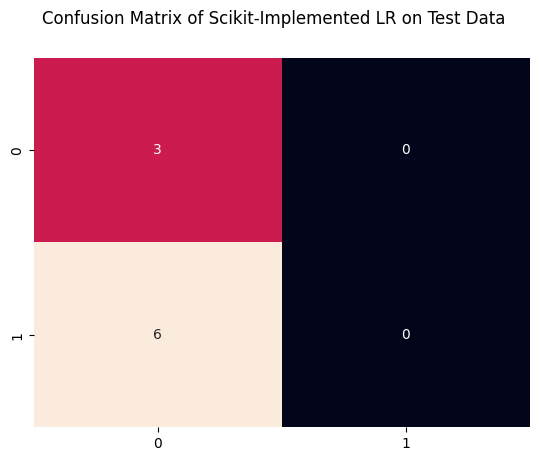

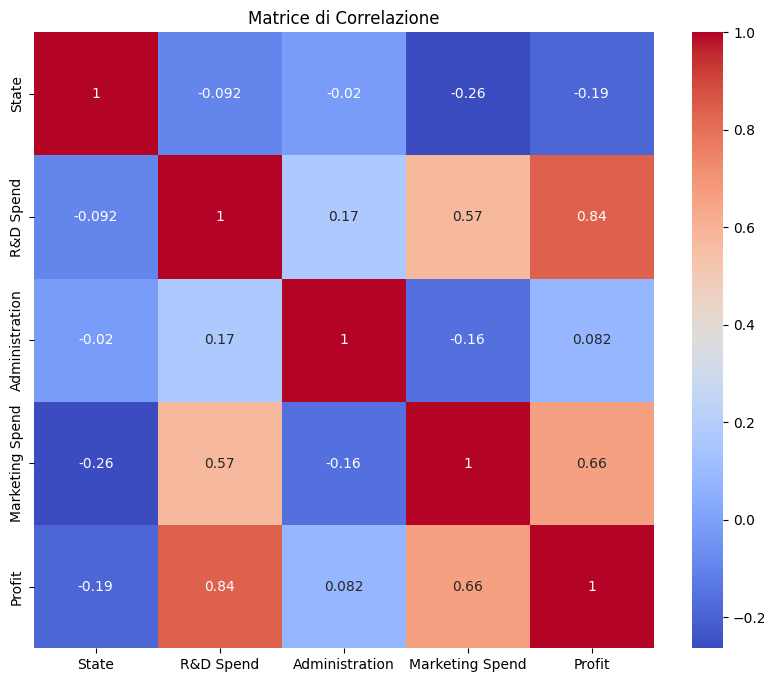

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

M_test = confusion_matrix(y_test, predictions)

sns.heatmap(M_test, annot=True, cbar=False)
plt.suptitle("Confusion Matrix of Scikit-Implemented LR on Test Data")
plt.show()

corr_matrix = df_fin.corr()

# Crea la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice di Correlazione')
plt.show()

***Add regularization***

Implement from scratch the regularized logistic regression model (with all the regularization techniques seen during the course).

L1 regularization (LASSO)
L2 regularitazion (Ridge)
Elastic Net Regularitazion

RIDGE

In [22]:
import numpy.linalg as LA
import numpy as np
from numpy.linalg import inv
from sklearn.metrics import log_loss


Funzione sigmoide per regressione logistica

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Regressione logistica

In [ ]:
def LogisticLoss(X, labels, w):
    
    n = np.shape(X)[0]
    cost = -(1/n)*np.sum(labels*np.log(sigmoid(w)) + (1-labels)*np.log(1-sigmoid(w)))
    return cost

In [ ]:
def logistic_regression(X, y, lr =0.01, num_iter=1000):
    """
    Implementa la regressione logistica senza regolarizzazione.
    """
    m, n = X.shape
    w = np.zeros(n)
    cost_history = []

    for i in range(num_iter):
        z = np.dot(X, w)
        h = sigmoid(z)
        gradient = (1 / m) * np.dot(X.T, (h - y))
        w -= lr * gradient
        log_loss()        
        cost =  LogisticLoss(y, [0.1], h)
        cost_history.append(cost)

    return w, cost_history

RIDGE REGRESSION

implementazione della regressione logistica con regolarizzazione L2

In [26]:
def logistic_regression_ridge(X, y, lr=0.01, num_iter=1000, lam=0.1):
    
    m, n = X.shape
    w = np.zeros(n)
    costs = []


    for _ in range(num_iter):
        z = X @ w
        h = 1 / (1 + np.exp(-z))
        gradient = (X.T @ (h - y)) / m + (lam / m) * w
        w -= lr * gradient

        cost = log_loss(y, h, labels=[0, 1]) + (lam / (2 * m)) * np.sum(w**2)
        costs.append(cost)

    return w, costs

LASSO

implementazione della regressione logistica con regolarizzazione L1

In [27]:
def logistic_regression_lasso(X, y, lr=0.01, num_iter=1000, lam=0.1):
    m, n = X.shape
    w = np.zeros(n)
    costs = []
    

    for _ in range(num_iter):
        z = X @ w
        h = 1 / (1 + np.exp(-z))

        gradient = (X.T @ (h - y)) / m + (lam / m)  * np.sign(w)
        w -= lr * gradient

        cost = log_loss(y, h, labels=[0, 1]) + (lam / m)* np.sum(np.abs(w))
        costs.append(cost)

    return w, costs

ELASTIC NET
implementazione della regressione logistica con elastic net

In [37]:
def logistic_regression_elasticnet(X, y, lr=0.01, num_iter=1000, lam1=0.1, lam2=0.1):
    m, n = X.shape
    w = np.zeros(n)
    costs= []
    lam1_over_m = lam1 / m
    lam2_over_m = lam2 / m

    for _ in range(num_iter):
        z = X @ w
        h = 1 / (1 + np.exp(-z))
        reg_term = lam1_over_m * np.sign(w) + lam2_over_m * w
        gradient = (X.T @ (h - y)) / m + reg_term
        w -= lr * gradient

        cost = log_loss(y, h, labels=[0, 1]) + lam1_over_m * np.sum(np.abs(w)) + (lam2 / (2 * m)) * np.sum(w**2)
        costs.append(cost)

    return w, costs

***Model assessment***

Given true and predicted values, compute the most common classification metrics to assess the quality of your predictions.

In [29]:
from sklearn.metrics import classification_report
y_true = y_test
y_pred = LR.predict(X_test)

target_names = ['California', 'Florida']
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  California       0.33      1.00      0.50         3
     Florida       0.00      0.00      0.00         6

    accuracy                           0.33         9
   macro avg       0.17      0.50      0.25         9
weighted avg       0.11      0.33      0.17         9



c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Repeat the previous task for regularized logistic regression and compare the results.

In [30]:

def normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    return (X - mu) / sigma

def bias(X):
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

# Normalizza le caratteristiche di X_train e X_test
X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)

# Aggiungi il termine di bias
X_train_bias = bias(X_train_norm)
X_test_bias = bias(X_test_norm)

In [ ]:
learning_rate = 0.05
iters = 10000
lambda_l1 = 0.01  # Coefficiente di regolarizzazione L1
lambda_l2 = 0.01  # Coefficiente di regolarizzazione L2

theta_ridge, cost_history_ridge = logistic_regression_ridge( X_train_bias, y_train, lr=learning_rate, num_iter=iters, lam=lambda_l2)

theta_lasso, cost_history_lasso = logistic_regression_lasso( X_train_bias, y_train, lr=learning_rate, num_iter=iters, lam=lambda_l1 )

theta_elasticnet, cost_history_elasticnet = logistic_regression_elasticnet( X_train_bias, y_train, lr=learning_rate, num_iter=iters, lam1=lambda_l1, lam2=lambda_l2 )

In [32]:
def predict(X, theta):
    probabilities = sigmoid(np.dot(X, theta))
    return probabilities

def predict_classes(X, theta):
    probabilities = predict(X, theta)
    return np.where(probabilities >= 0.5, 1, 0)

In [ ]:
# Predizioni per il modello Ridge
y_ridge = predict_classes(X_test_bias, theta_ridge)

# Predizioni per il modello Lasso
y_lasso = predict_classes(X_test_bias, theta_lasso)

# Predizioni per il modello Elastic Net
y_elasticnet = predict_classes(X_test_bias, theta_elasticnet)




array([0, 1, 0, 1, 0, 0, 0, 1, 1])

Creazione del reporto per tutti i modelli con diversa regolarizzazione

In [34]:
from sklearn.metrics import classification_report

target_names = ['California', 'Florida']

# Report per il modello Ridge
print("Report di Classificazione per la Regressione Logistica Ridge:")
print(classification_report(y_test, y_ridge, target_names=target_names))

# Report per il modello Lasso
print("Report di Classificazione per la Regressione Logistica Lasso:")
print(classification_report(y_test, y_lasso, target_names=target_names))

# Report per il modello Elastic Net
print("Report di Classificazione per la Regressione Logistica Elastic Net:")
print(classification_report(y_test, y_elasticnet, target_names=target_names))

Report di Classificazione per la Regressione Logistica Ridge:
              precision    recall  f1-score   support

  California       0.20      0.33      0.25         3
     Florida       0.50      0.33      0.40         6

    accuracy                           0.33         9
   macro avg       0.35      0.33      0.33         9
weighted avg       0.40      0.33      0.35         9

Report di Classificazione per la Regressione Logistica Lasso:
              precision    recall  f1-score   support

  California       0.20      0.33      0.25         3
     Florida       0.50      0.33      0.40         6

    accuracy                           0.33         9
   macro avg       0.35      0.33      0.33         9
weighted avg       0.40      0.33      0.35         9

Report di Classificazione per la Regressione Logistica Elastic Net:
              precision    recall  f1-score   support

  California       0.20      0.33      0.25         3
     Florida       0.50      0.33      0.40  

In [ ]:
M_test = confusion_matrix(y_test, predictions)


***ROC curve***

Implement a function for producing the Receiver Operating Characteristic (ROC) curve.

Given true and predicted values, plot the ROC curve using your implemented function.

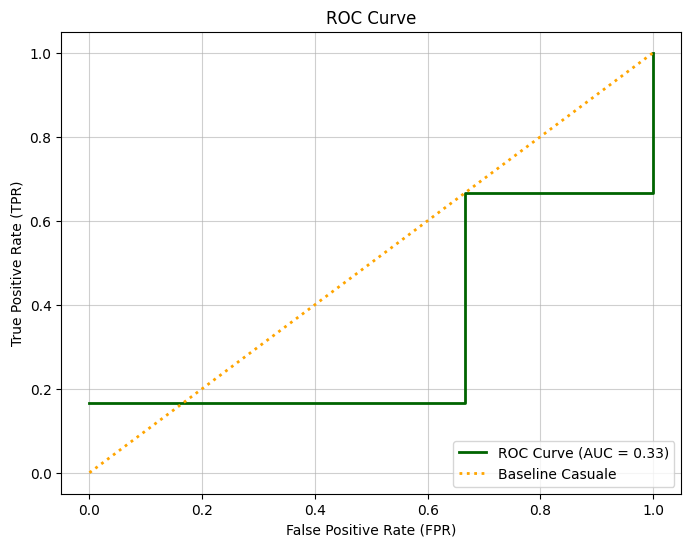

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_roc_coords(true_labels, predicted_scores):
    """
    Calcola le coordinate della curva ROC (FPR, TPR) iterando sulle soglie uniche.

    Args:
        true_labels (array-like): Vettore delle etichette vere (0 o 1).
        predicted_scores (array-like): Vettore dei punteggi predetti.

    Returns:
        false_positive_rate (array): Tassi di falsi positivi (FPR).
        true_positive_rate (array): Tassi di veri positivi (TPR).
        unique_thresholds (array): Soglie calcolate.
    """
    # Converti in array numpy e assicurati che y_true sia binario
    true_labels = np.asarray(true_labels)
    predicted_scores = np.asarray(predicted_scores)

    # Identifica il numero totale di positivi (P) e negativi (N)
    P = np.sum(true_labels == 1)
    N = np.sum(true_labels == 0)

    # Ottieni tutte le soglie uniche ordinandole in ordine decrescente
    unique_thresholds = np.unique(predicted_scores)
    unique_thresholds = np.append(unique_thresholds[::-1], 0.0) # Aggiunge 0 per il punto finale (1, 1)

    tpr_coords = []
    fpr_coords = []

    for thresh in unique_thresholds:
        # Classifica i campioni usando la soglia attuale
        y_pred = (predicted_scores >= thresh).astype(int)

        # Calcola i conteggi della matrice di confusione
        # TP: y_pred=1 E y_true=1
        TP = np.sum((y_pred == 1) & (true_labels == 1))
        # FP: y_pred=1 E y_true=0
        FP = np.sum((y_pred == 1) & (true_labels == 0))

        # Calcola i tassi
        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0

        tpr_coords.append(TPR)
        fpr_coords.append(FPR)

    return np.array(fpr_coords), np.array(tpr_coords), np.array(unique_thresholds)


y_score_values = LR.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, score_thresholds = calculate_roc_coords(y_test, y_score_values)

area_under_curve = np.trapezoid(true_positive_rate, false_positive_rate) 

# Traccia la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {area_under_curve:.2f})')
plt.plot([0, 1], [0, 1], color='orange', lw=2, linestyle=':', label='Baseline Casuale')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.6)
plt.show()

ROC PER I MODELLI CON REGOLARIZZAZIONE